In [6]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [10]:
df=pd.read_csv("https://github.com/rishabhnmishra/Python_Diwali_Sales_Analysis/raw/refs/heads/main/Diwali%20Sales%20Data.csv",encoding='unicode_escape')

In [11]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount,Status,unnamed1
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0,NaN,NaN
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0,NaN,NaN
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0,NaN,NaN
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0,NaN,NaN
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0,NaN,NaN


In [87]:
df.shape

(11251, 15)

In [88]:
df.drop(['Status','unnamed1'],axis=1,inplace=True)

In [89]:
df.head()

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Marital_Status,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952.0
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934.0
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924.0
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912.0
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877.0


In [90]:
df.isnull().sum()

User_ID              0
Cust_name            0
Product_ID           0
Gender               0
Age Group            0
Age                  0
Marital_Status       0
State                0
Zone                 0
Occupation           0
Product_Category     0
Orders               0
Amount              12
dtype: int64

In [91]:
df.dropna(inplace=True)

In [92]:
df.isnull().sum()

User_ID             0
Cust_name           0
Product_ID          0
Gender              0
Age Group           0
Age                 0
Marital_Status      0
State               0
Zone                0
Occupation          0
Product_Category    0
Orders              0
Amount              0
dtype: int64

In [24]:
df.info()

<class 'pandas.DataFrame'>
Index: 11239 entries, 0 to 11250
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   User_ID           11239 non-null  int64 
 1   Cust_name         11239 non-null  str   
 2   Product_ID        11239 non-null  str   
 3   Gender            11239 non-null  str   
 4   Age Group         11239 non-null  str   
 5   Age               11239 non-null  int64 
 6   Marital_Status    11239 non-null  int64 
 7   State             11239 non-null  str   
 8   Zone              11239 non-null  str   
 9   Occupation        11239 non-null  str   
 10  Product_Category  11239 non-null  str   
 11  Orders            11239 non-null  int64 
 12  Amount            11239 non-null  object
dtypes: int64(4), object(1), str(8)
memory usage: 1.2+ MB


In [93]:
df['Amount']=pd.to_numeric(df['Amount'],errors='coerce')

In [95]:
df['Amount']=df['Amount'].astype('int64')

In [96]:
df['Amount'].dtype

dtype('int64')

In [97]:
df.columns

Index(['User_ID', 'Cust_name', 'Product_ID', 'Gender', 'Age Group', 'Age',
       'Marital_Status', 'State', 'Zone', 'Occupation', 'Product_Category',
       'Orders', 'Amount'],
      dtype='str')

In [98]:
df.rename(columns={'Marital_Status':'Shadi'})

,User_ID,Cust_name,Product_ID,Gender,Age Group,Age,Shadi,State,Zone,Occupation,Product_Category,Orders,Amount
0,1002903,Sanskriti,P00125942,F,26-35,28,0,Maharashtra,Western,Healthcare,Auto,1,23952
1,1000732,Kartik,P00110942,F,26-35,35,1,Andhra Pradesh,Southern,Govt,Auto,3,23934
2,1001990,Bindu,P00118542,F,26-35,35,1,Uttar Pradesh,Central,Automobile,Auto,3,23924
3,1001425,Sudevi,P00237842,M,0-17,16,0,Karnataka,Southern,Construction,Auto,2,23912
4,1000588,Joni,P00057942,M,26-35,28,1,Gujarat,Western,Food Processing,Auto,2,23877
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11246,1000695,Manning,P00296942,M,18-25,19,1,Maharashtra,Western,Chemical,Office,4,370
11247,1004089,Reichenbach,P00171342,M,26-35,33,0,Haryana,Northern,Healthcare,Veterinary,3,367
11248,1001209,Oshin,P00201342,F,36-45,40,0,Madhya Pradesh,Central,Textile,Office,4,213
11249,1004023,Noonan,P00059442,M,36-45,37,0,Karnataka,Southern,Agriculture,Office,3,206


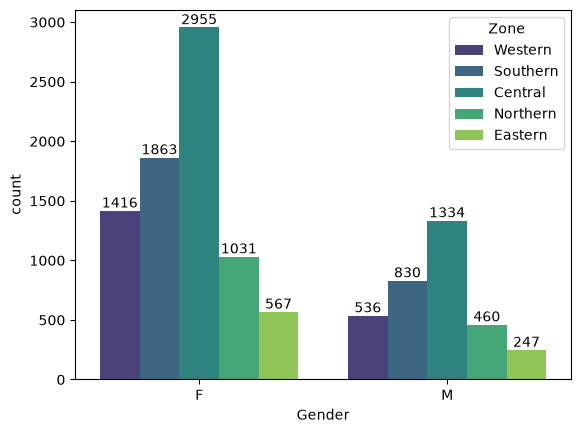

In [52]:
ax=sns.countplot(x='Gender',data=df,hue='Zone',palette='viridis')
for i in ax.containers:
    ax.bar_label(i)

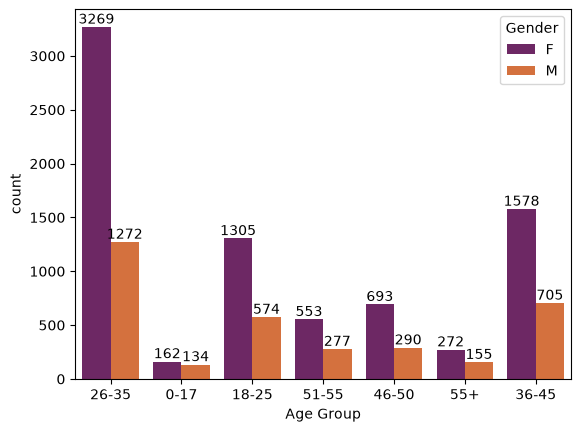

In [107]:
ax=sns.countplot(x='Age Group',data=df,hue='Gender',palette='inferno')
for i in ax.containers:
    ax.bar_label(i)

C:\Users\DELL\AppData\Local\Temp\ipykernel_17768\236819995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = 'Age Group',y= 'Amount' ,data = sales_age,palette='plasma')


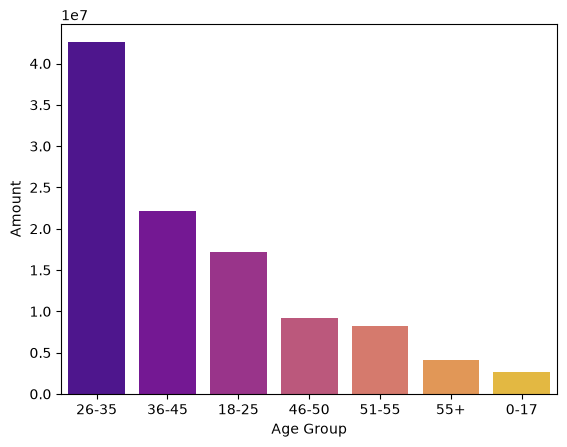

In [12]:
sales_age = df.groupby(['Age Group'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

sns.barplot(x = 'Age Group',y= 'Amount' ,data = sales_age,palette='plasma')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_17768\2157017082.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = sales_state, x = 'State',y= 'Orders',palette='RdBu')


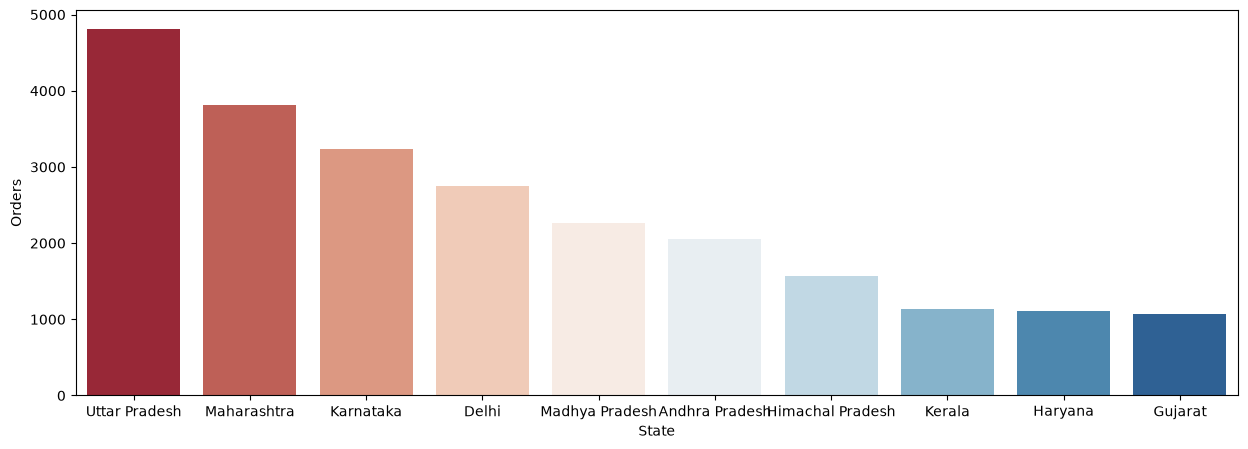

In [17]:
# total number of orders from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

plt.figure(figsize=(15,5))
sns.barplot(data = sales_state, x = 'State',y= 'Orders',palette='RdBu')
plt.show()

                         Total number of orders from top 10 states

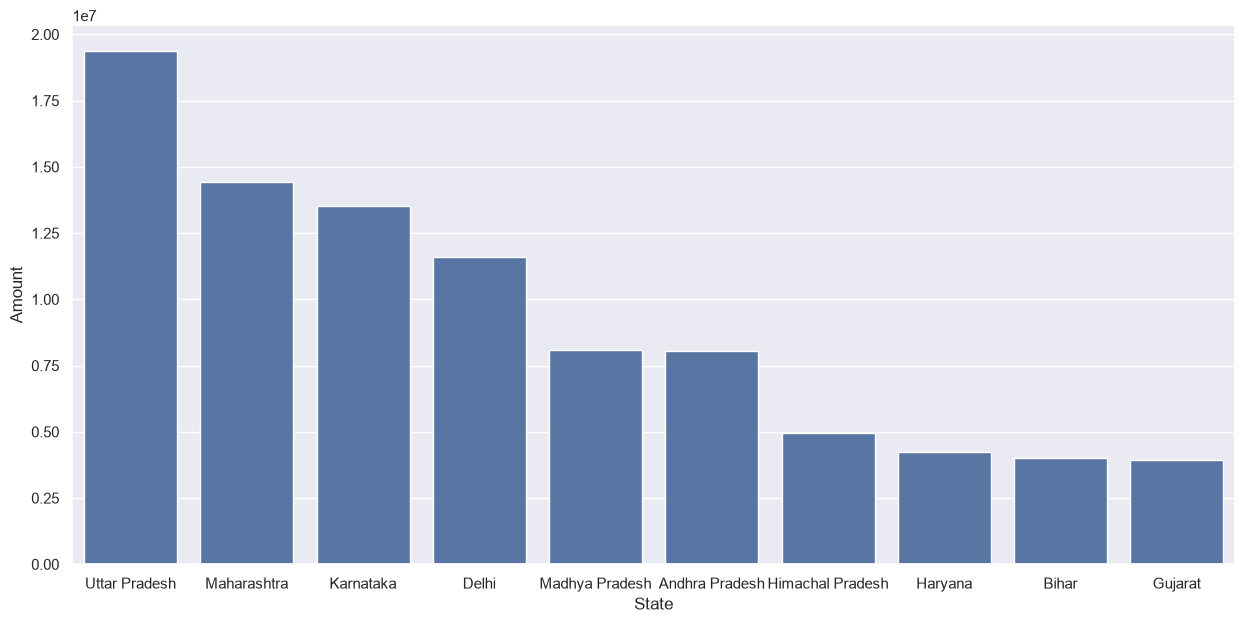

In [128]:
# total amount/sales from top 10 states

sales_state = df.groupby(['State'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)

plt.figure(figsize=(15,7))
sns.barplot(data = sales_state, x = 'State',y= 'Amount')
plt.show()

In [19]:
ax = sns.countplot(data = df, x = 'Marital_Status',palette='mako')

plt.figure(figsize=(15,7))
for bars in ax.containers:
    ax.bar_label(bars)

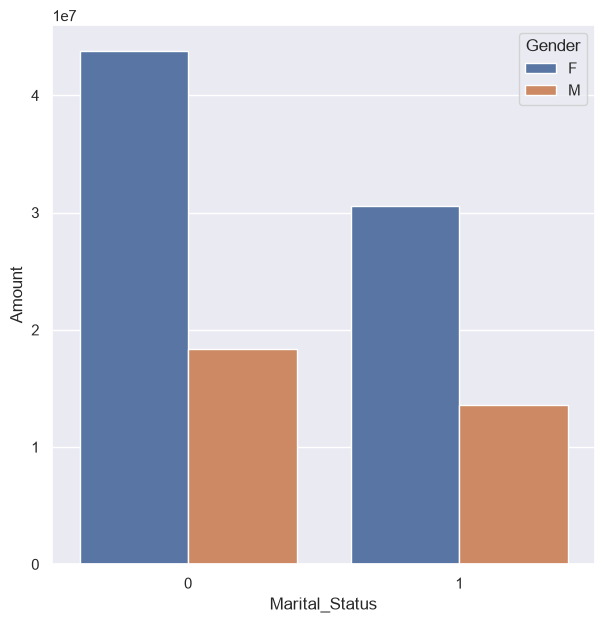

In [131]:
sales_state = df.groupby(['Marital_Status', 'Gender'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(7,7))
sns.barplot(data = sales_state, x = 'Marital_Status',y= 'Amount', hue='Gender')
plt.show()

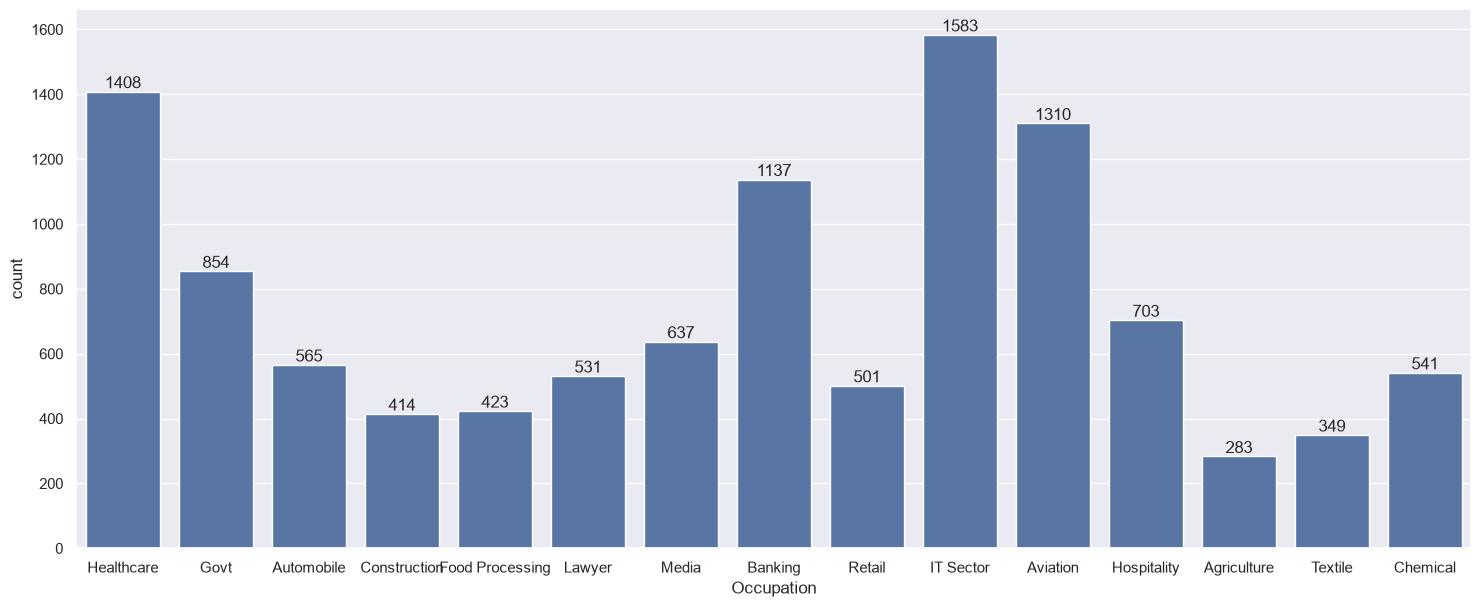

In [133]:
plt.figure(figsize=(18,7))
ax = sns.countplot(data = df, x = 'Occupation')

for bars in ax.containers:
    ax.bar_label(bars)

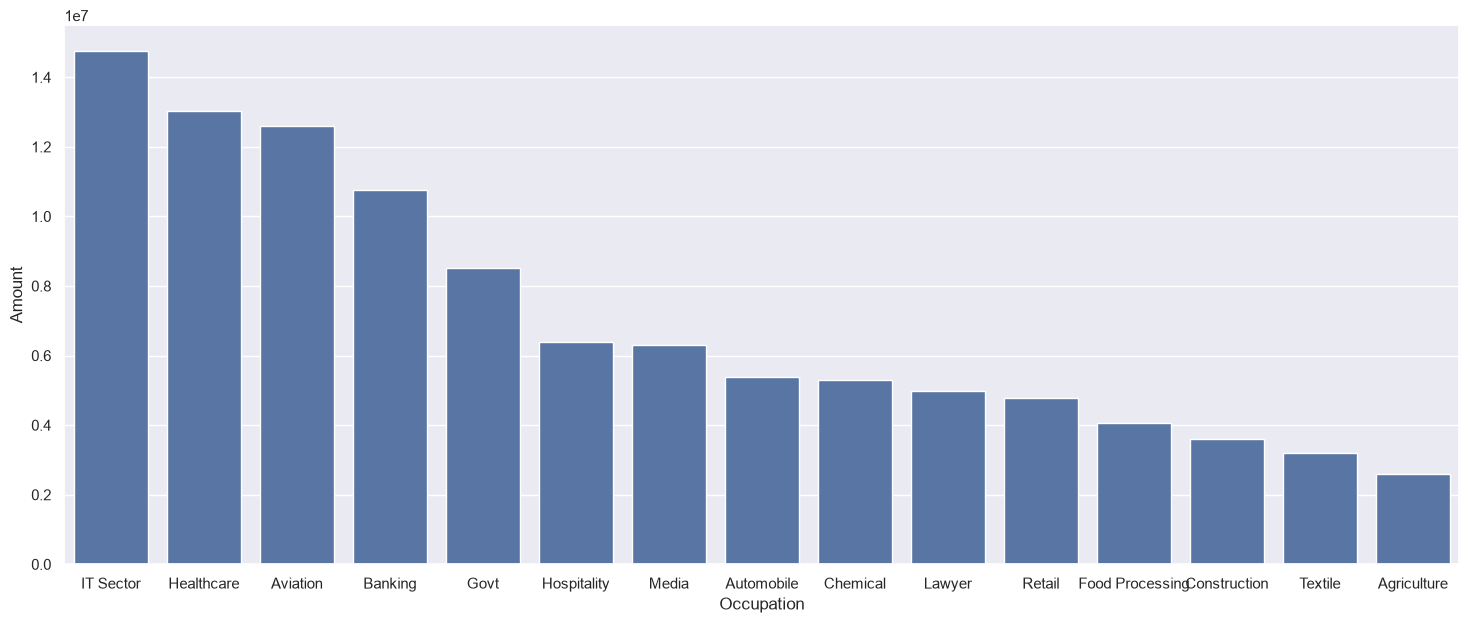

In [135]:
sales_state = df.groupby(['Occupation'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False)

plt.figure(figsize=(18,7))
sns.barplot(data = sales_state, x = 'Occupation',y= 'Amount')
plt.show()

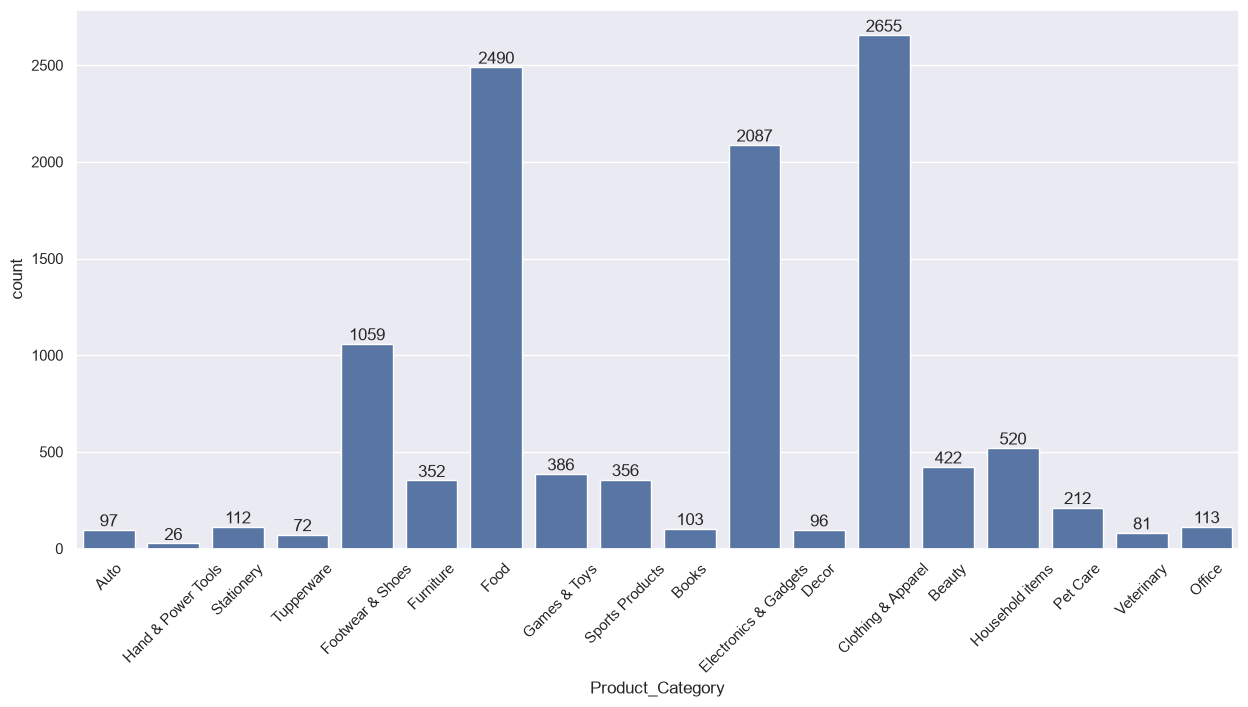

In [137]:
plt.figure(figsize=(15,7))
ax = sns.countplot(data = df, x = 'Product_Category')
plt.xticks(rotation=45)

for bars in ax.containers:
    ax.bar_label(bars)

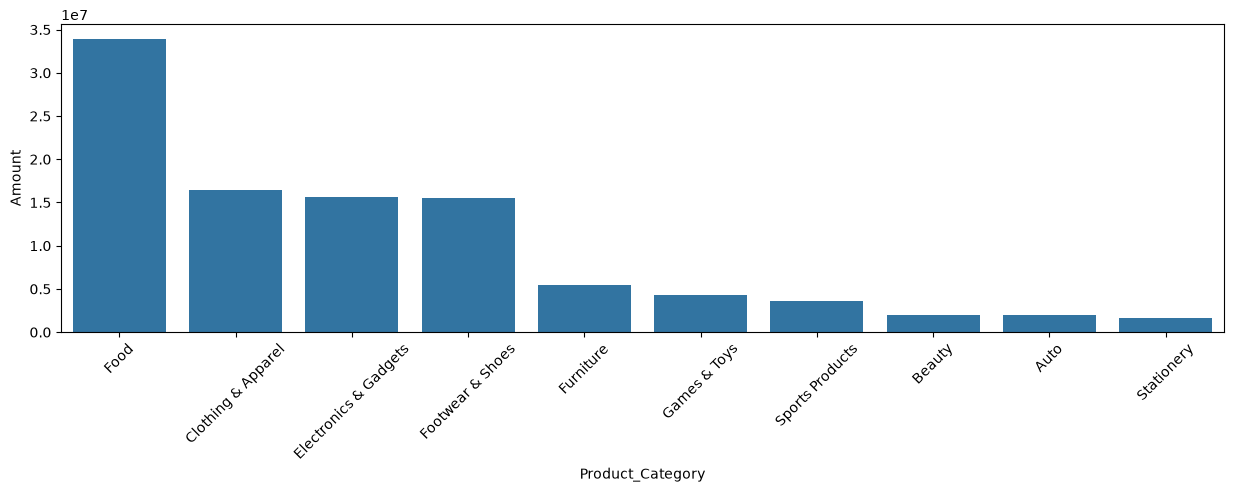

In [20]:
plt.figure(figsize=(15,4))
sales_state = df.groupby(['Product_Category'], as_index=False)['Amount'].sum().sort_values(by='Amount', ascending=False).head(10)
plt.xticks(rotation=45)

sns.barplot(data = sales_state, x = 'Product_Category',y= 'Amount')
plt.show()

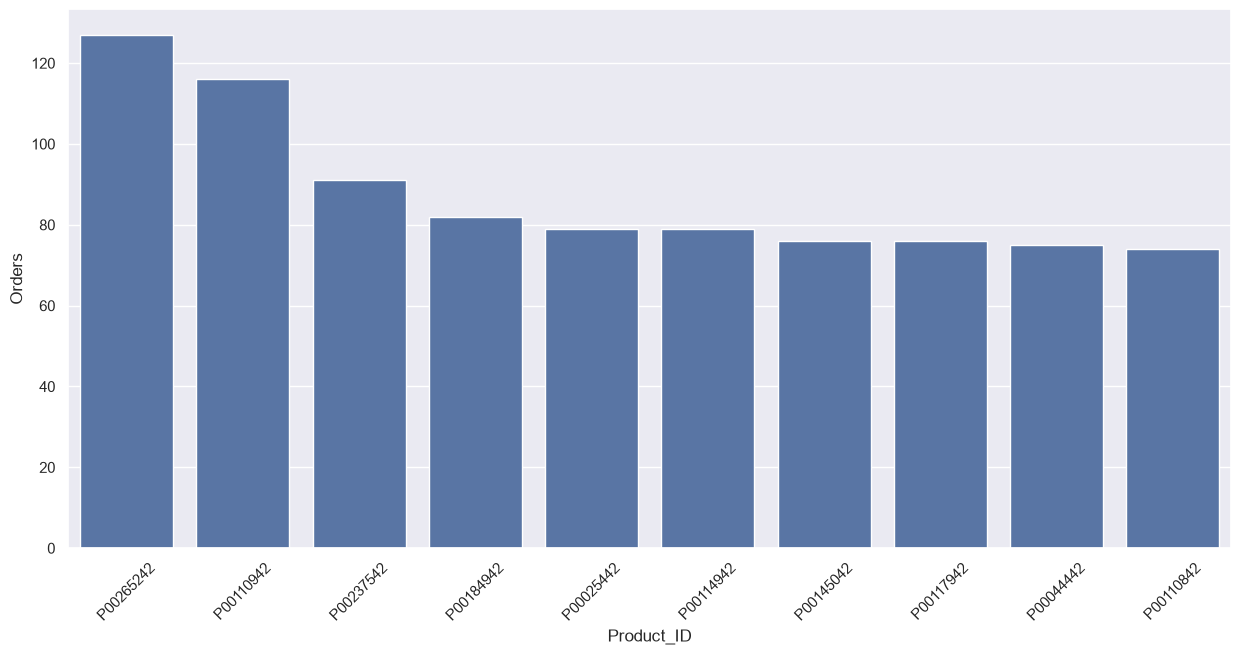

In [141]:
sales_state = df.groupby(['Product_ID'], as_index=False)['Orders'].sum().sort_values(by='Orders', ascending=False).head(10)

plt.figure(figsize=(15,7))
plt.xticks(rotation=45)
sns.barplot(data = sales_state, x = 'Product_ID',y= 'Orders')
plt.show()